In [11]:
# import basics and main libraries 
import os 
import numpy as np
import pandas as pd
import seaborn as sns 
from matplotlib import pyplot as plt

In [13]:
# checking the current directory yo find the date
os.getcwd()

'C:\\Users\\MI\\churn_project'

# Data Prepration

In [15]:
# Read and load the CSV file into dataframe 
df = pd.read_csv('churn-bigml-80.csv') # This is a training data, not the whole data 
# Display the first few rows of the DataFrame
df.head().T

,0,1,2,3,4
State,KS,OH,NJ,OH,OK
Account length,128,107,137,84,75
Area code,415,415,415,408,415
International plan,No,No,No,Yes,Yes
Voice mail plan,Yes,Yes,No,No,No
Number vmail messages,25,26,0,0,0
Total day minutes,265.1,161.6,243.4,299.4,166.7
Total day calls,110,123,114,71,113
Total day charge,45.07,27.47,41.38,50.9,28.34
Total eve minutes,197.4,195.5,121.2,61.9,148.3


In [17]:
# Display a summary of the dataframe to get some insights 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

### This data is for 2666 customers supported by 19 features and 1 target whic is Churn column. The most of the data types are accurate 

In [20]:
# Dispaly descriptive statsitics for the dataframe 
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [22]:
# Dispaly descriptive statsitics for object-type columns 
df.describe(include='object')

,State,International plan,Voice mail plan
count,2666,2666,2666
unique,51,2,2
top,WV,No,No
freq,88,2396,1933


In [24]:
# Check for missing values in the dataframe 
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [26]:
# Check for duplicated values in the dataframe 
df.duplicated().sum()

0

In [28]:
# Function checks if any elements equal to a space character (' ')
space_check = df.applymap(lambda x:x == ' ')
print(space_check.sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


C:\Users\MI\AppData\Local\Temp\ipykernel_13460\38471154.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  space_check = df.applymap(lambda x:x == ' ')


### The dataframe is clean, after analysing the data, it can be said that no missing, dublicated values or space, so the data is ready to next stage.

In [31]:
# Drop the 'Area code' column from the DataFrame as it is considered less important for analysis
df.drop('Area code', axis=1, inplace = True)
df.head()

,State,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


# Cleaning Stage

In [34]:
# enchur columns after droping 'Area code'
df.columns 

Index(['State', 'Account length', 'International plan', 'Voice mail plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls', 'Churn'],
      dtype='object')

In [36]:
# Display some rows for true Churn values
df[df.Churn == True]

,State,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
18,CO,77,No,No,0,62.4,89,10.61,169.9,121,14.44,209.6,64,9.43,5.7,6,1.54,5,True
28,AZ,12,No,No,0,249.6,118,42.43,252.4,119,21.45,280.2,90,12.61,11.8,3,3.19,1,True
35,MD,135,Yes,Yes,41,173.1,85,29.43,203.9,107,17.33,122.2,78,5.50,14.6,15,3.94,0,True
45,WY,87,No,No,0,151.0,83,25.67,219.7,116,18.67,203.9,127,9.18,9.7,3,2.62,5,True
48,CO,121,No,Yes,30,198.4,129,33.73,75.3,77,6.40,181.2,77,8.15,5.8,3,1.57,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2631,MI,119,Yes,Yes,22,172.1,119,29.26,223.6,133,19.01,150.0,94,6.75,13.9,20,3.75,1,True
2641,IL,71,Yes,No,0,186.1,114,31.64,198.6,140,16.88,206.5,80,9.29,13.8,5,3.73,4,True
2656,GA,122,Yes,No,0,140.0,101,23.80,196.4,77,16.69,120.1,133,5.40,9.7,4,2.62,4,True
2657,MD,62,No,No,0,321.1,105,54.59,265.5,122,22.57,180.5,72,8.12,11.5,2,3.11,4,True


In [38]:
# Transform the data type of Churn column fron boolean to integer 
df.Churn = (df.Churn == True).astype(int)

In [40]:
# Display the numbers of churn and non-churn customers to check balance and imbalance 
df.Churn.value_counts() 

Churn
0    2278
1     388
Name: count, dtype: int64

In [42]:
# Normalization the churn values
df.Churn.value_counts(normalize= True)

Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64

In [44]:
# Calculate the churn average to use it as a refrence with other features 
global_mean = df.Churn.mean()
print(global_mean)

0.145536384096024


# EDA

In [47]:
# Split the Features into two list 
Categorical = list(df.select_dtypes(include=['object']).columns)
Numerical = list(df.select_dtypes(include=['number']).columns)

In [49]:
# Remove the Target Column from the numerical list
Numerical.remove('Churn')
print(Numerical)

['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [51]:
# Display the unique values in categorical data 
df[Categorical].nunique()

State                 51
International plan     2
Voice mail plan        2
dtype: int64

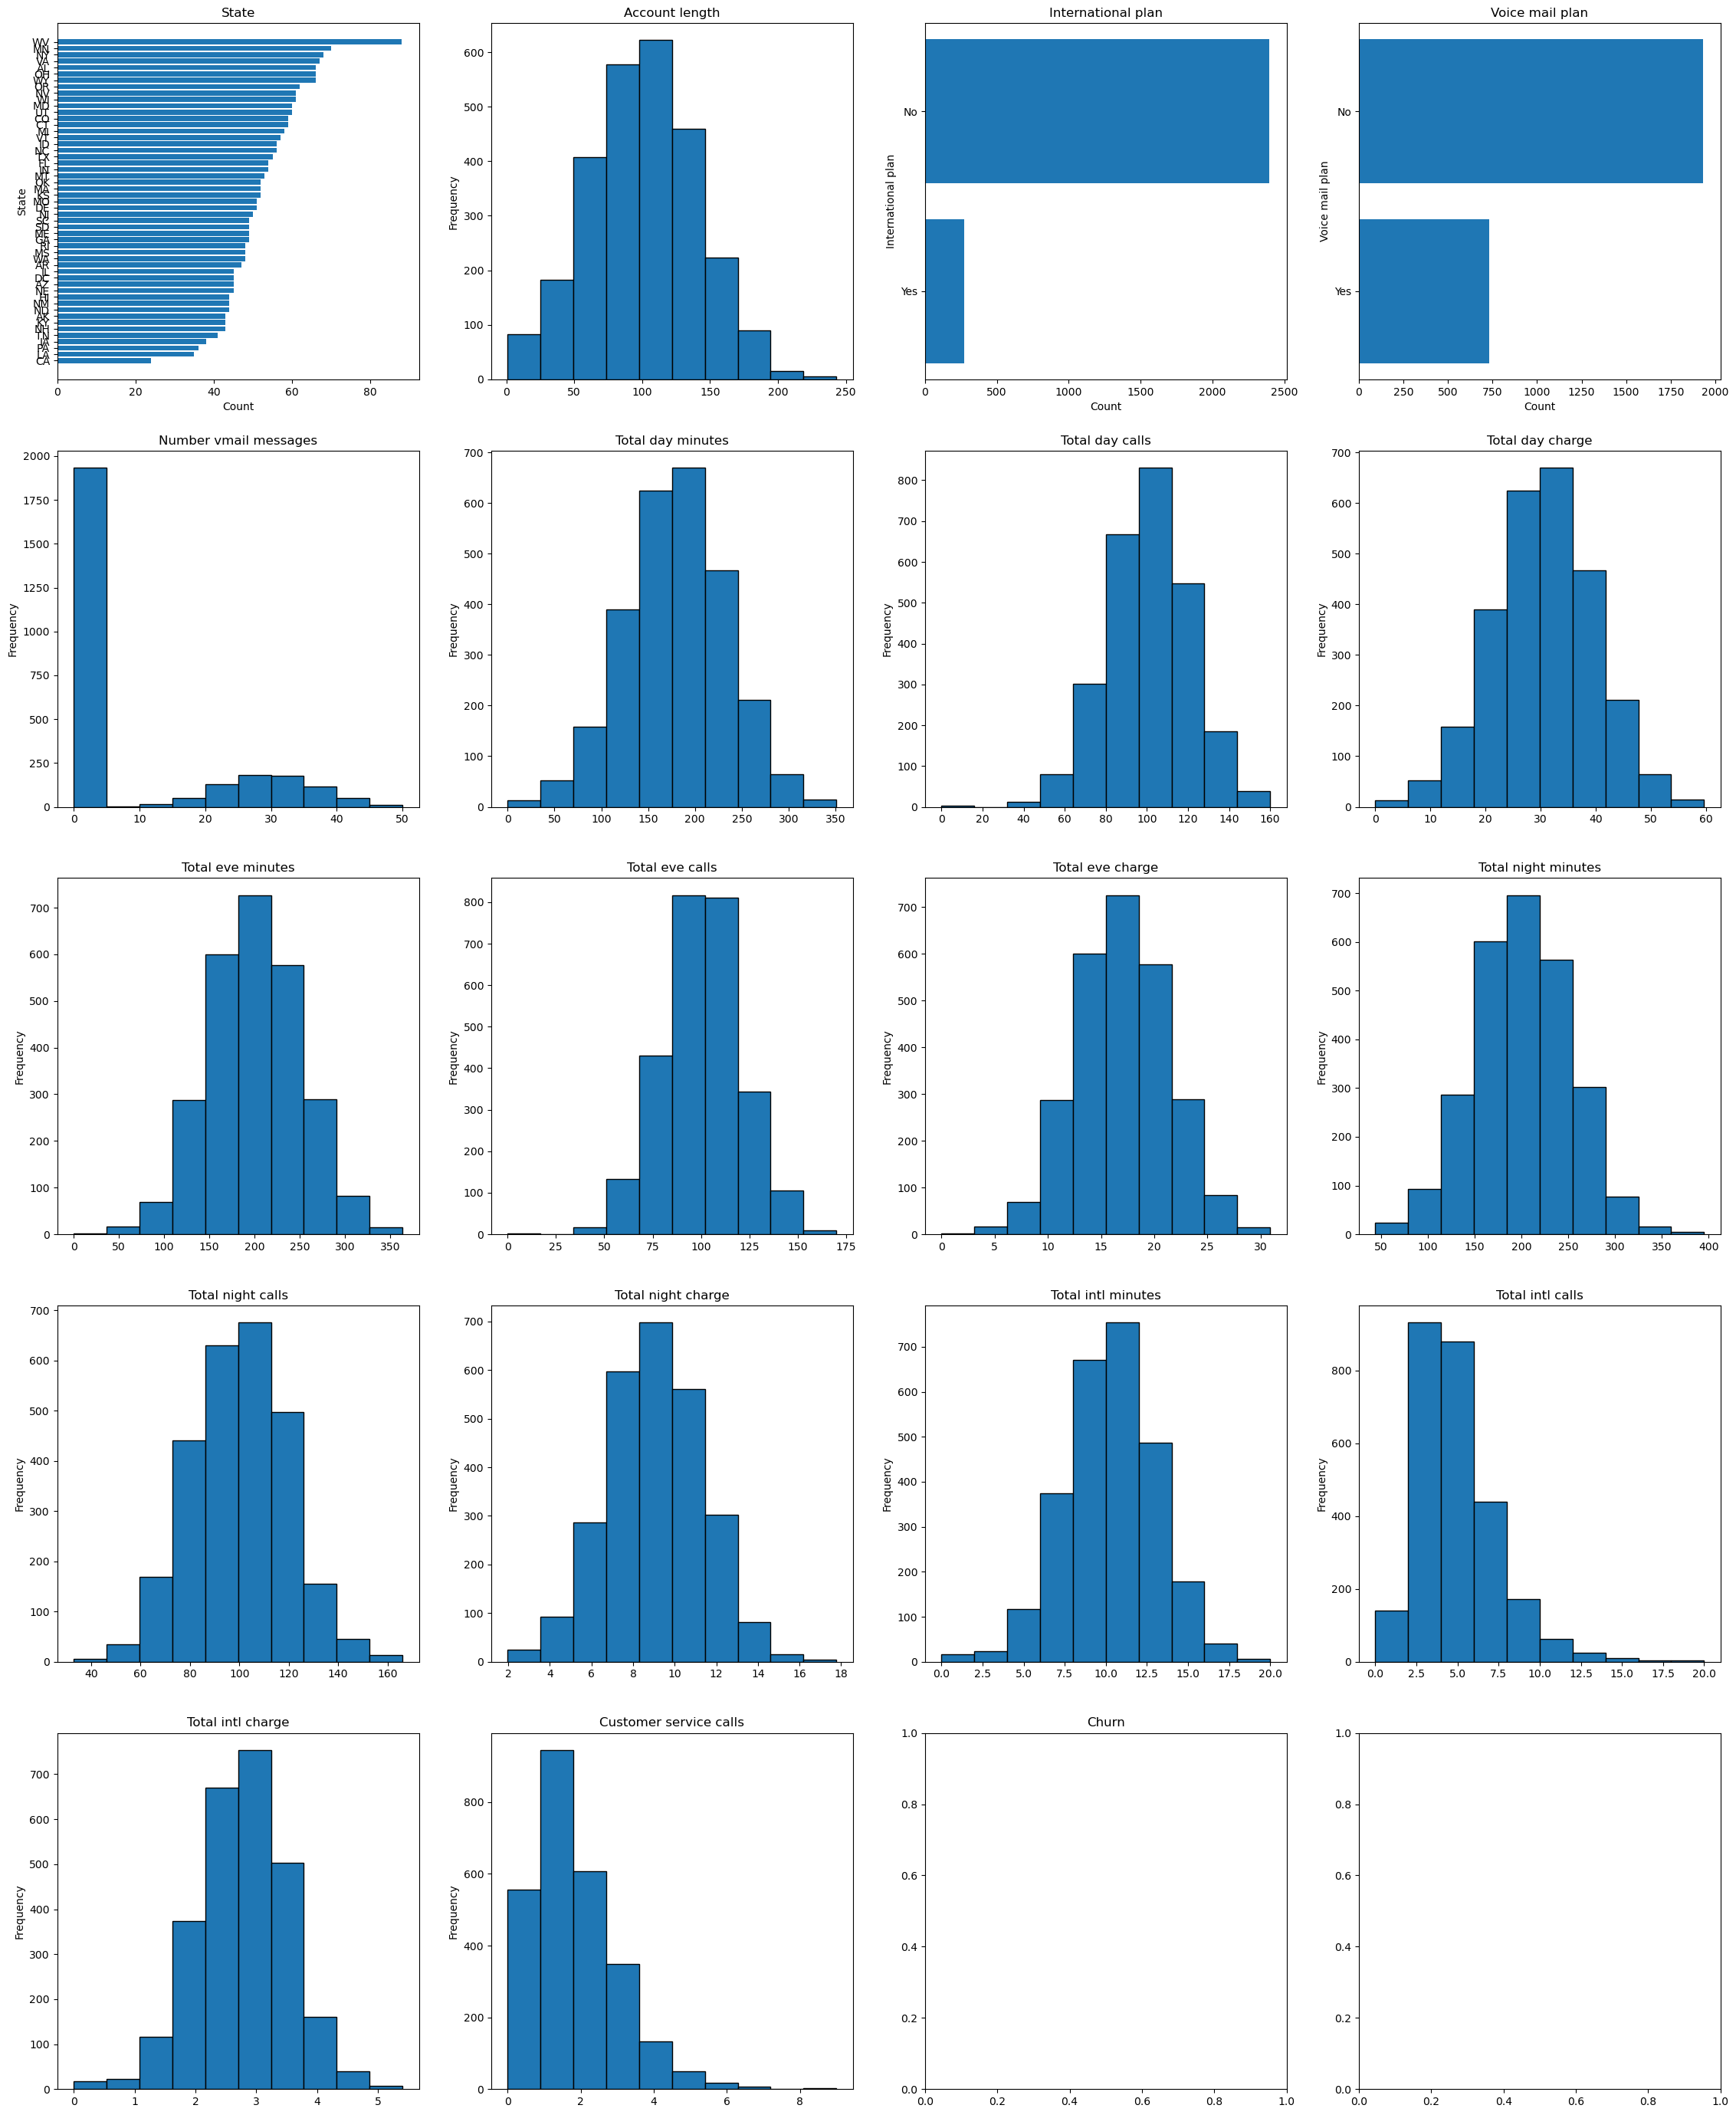

In [53]:
#visualize distribution for each column
fig, axes = plt.subplots(5, 4, figsize=(28, 35))
for ax, col in zip(axes.flatten(), df.columns):
    ax.set_title(col)
    if df[col].dtype == 'object':
        ax.barh(df[col].value_counts().index, df[col].value_counts())
        ax.set_xlabel('Count')
        ax.set_ylabel(col)
        ax.invert_yaxis()
    else:
        if df[col].dtype == 'float64' or df[col].dtype == 'int64':
            df[col].plot(kind="hist", ec="black", ax=ax)
plt.show()

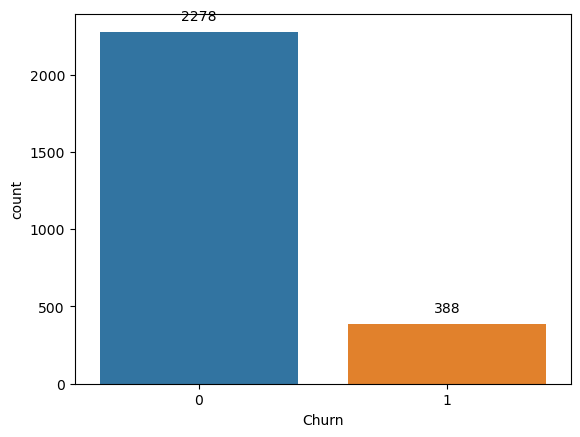

In [54]:
#visualize distribution for churn column
churn_count = df['Churn'].value_counts()
ax = sns.countplot(data = df , x ='Churn' , palette='tab10' , hue = 'Churn' , legend=False)


for i in range(churn_count.shape[0]):
    count = churn_count.iloc[i]
    x = i
    y =count+100
    ax.annotate(count,(x,y) , ha ='center' , va ='center')
    

plt.show()

## The visualiztion reflects that the total numbers of churn customers is 388, while the total of non-churn numbers is 2278. 

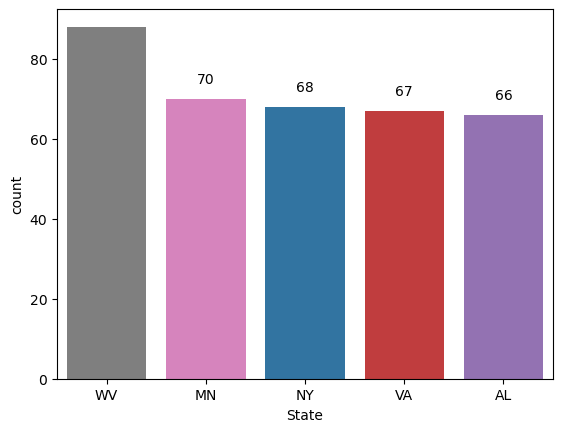

In [56]:
#visualize distribution for state column
state_count = df['State'].value_counts()

ax = sns.countplot(data=df, x='State', palette='tab10', order=state_count.index[:5] , hue ='State' , legend =False)

for i in range(5):
    count = state_count.iloc[i]
    x = i
    y = count +5
    ax.annotate(count, (x, y), ha='center', va='center')

plt.show()

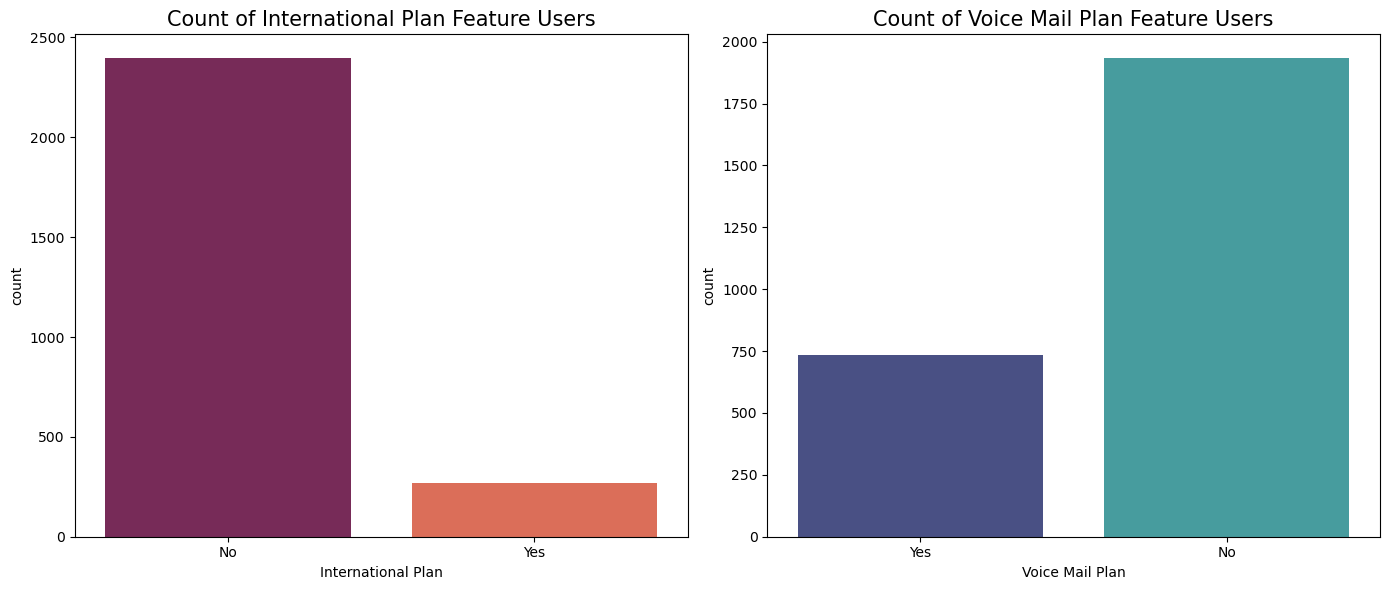

In [57]:
#visualize distribution for International plan and Voice mail plan columns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.countplot(data=df, x='International plan', palette='rocket', hue='International plan', ax=axes[0], legend=False)
axes[0].set_title('Count of International Plan Feature Users', fontsize=15)
axes[0].set_xlabel('International Plan')


sns.countplot(data=df, x='Voice mail plan', palette='mako', hue='Voice mail plan', ax=axes[1], legend=False)
axes[1].set_title('Count of Voice Mail Plan Feature Users', fontsize=15)
axes[1].set_xlabel('Voice Mail Plan')


plt.tight_layout()


plt.show()

## Feature Importance

In [63]:
from IPython.display import display

for feature in Categorical:
    df_group = df.groupby(by= feature).Churn.agg(['mean'])
    df_difference = df_group['mean'] - global_mean
    df_risk = df_group['mean'] / global_mean
    display(df_group)

,mean
State,
AK,0.069767
AL,0.106061
AR,0.234043
AZ,0.066667
CA,0.208333
CO,0.118644
CT,0.186441
DC,0.111111
DE,0.156863


,mean
International plan,
No,0.112688
Yes,0.437037


,mean
Voice mail plan,
No,0.167098
Yes,0.088677


C:\Users\MI\AppData\Local\Temp\ipykernel_13460\626728237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x= feature, y = 'mean', data=df_group, palette='Greens')


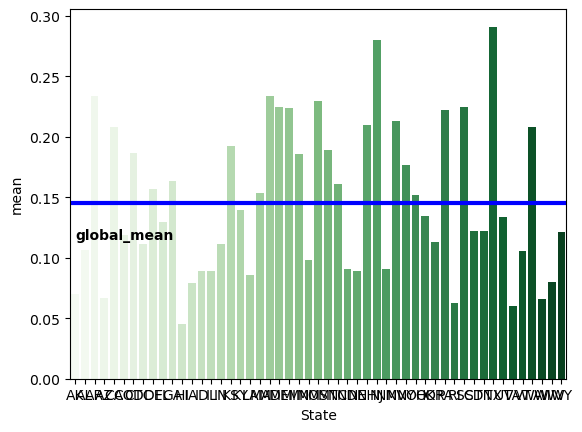

C:\Users\MI\AppData\Local\Temp\ipykernel_13460\626728237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x= feature, y = 'mean', data=df_group, palette='Greens')


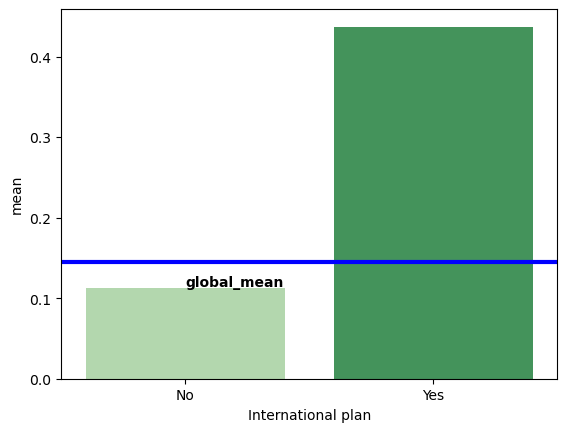

C:\Users\MI\AppData\Local\Temp\ipykernel_13460\626728237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x= feature, y = 'mean', data=df_group, palette='Greens')


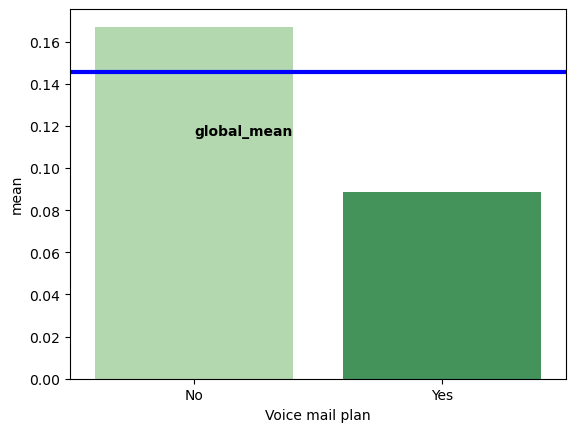

In [65]:
for feature in Categorical:                                           
    df_group = df.groupby(by=feature).Churn.agg(['mean']).reset_index()
    graph=sns.barplot(x= feature, y = 'mean', data=df_group, palette='Greens')
    graph.axhline(global_mean, linewidth=3, color='b')
    plt.text(0, global_mean - 0.03, "global_mean", color='black', weight='semibold')
    plt.show()

# Preprocessing

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from datasist.structdata import detect_outliers
# Models
from sklearn.linear_model import LogisticRegression , SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Data splitting

In [72]:
# Prepare features and target variable
x = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=1)

# Load test data
df_test = pd.read_csv('churn-bigml-20.csv')
x_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']

# Print sizes of datasets
print("Training data size: ", x_train.shape)
print("Validation data size: ", x_val.shape)
print("Testing data size: ", x_test.shape)

Training data size:  (2132, 18)
Validation data size:  (534, 18)
Testing data size:  (667, 19)


In [74]:
# Drop unnecessary columns from test data
x_test.drop('Area code', axis=1, inplace=True)

# Print data types
print(x_train.dtypes)
print(x_val.dtypes)
print(x_test.dtypes)

State                      object
Account length              int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
dtype: object
State                      object
Account length              int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64


In [76]:
# Detect outliers in the training data
outliers_indices = detect_outliers(df, 0, x_train.select_dtypes(include=['float64', 'int64']))
print(f"Outliers detected: {len(outliers_indices)}")

# Convert outliers_indices to a set for faster lookups
outliers_set = set(outliers_indices)

# Drop outliers from training data
x_train = x_train[~x_train.index.isin(outliers_set)]
y_train = y_train[~y_train.index.isin(outliers_set)]  # Ensure y_train matches x_train

# Print the new shape
print(f"New training data size: {x_train.shape}")

Outliers detected: 420
New training data size: (1801, 18)


In [78]:
# Define categorical and numerical columns
categorical_columns = x_train.select_dtypes(include=['object']).columns.tolist()
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

In [80]:
# Preprocessing function
def preprocess(df_train, df_valid, df_test, cat, num):
    # Define main transformer
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    scaler = StandardScaler()

    transformer = make_column_transformer(
        (encoder, cat), 
        (scaler, num), 
        remainder='passthrough', 
        verbose_feature_names_out=False
    )

    # Apply transformations and fit
    x_train = transformer.fit_transform(df_train)
    x_valid = transformer.transform(df_valid)
    x_test = transformer.transform(df_test)
    
    # Create DataFrames with feature names
    columns = transformer.get_feature_names_out()
    x_train = pd.DataFrame(x_train, columns=columns)
    x_valid = pd.DataFrame(x_valid, columns=columns)
    x_test = pd.DataFrame(x_test, columns=columns)

    return x_train, x_valid, x_test, columns

In [82]:
# Preprocess the datasets
x_train, x_val, x_test, columns = preprocess(x_train, x_val, x_test, categorical_columns, numerical_columns)

In [84]:
# Model evaluation function
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Evaluation Metrics
    metrics = {
        'Train': {
            'Accuracy': accuracy_score(y_train, y_train_pred),
            'Precision': precision_score(y_train, y_train_pred),
            'Recall': recall_score(y_train, y_train_pred),
            'F1 Score': f1_score(y_train, y_train_pred)
        },
        'Validation': {
            'Accuracy': accuracy_score(y_val, y_val_pred),
            'Precision': precision_score(y_val, y_val_pred),
            'Recall': recall_score(y_val, y_val_pred),
            'F1 Score': f1_score(y_val, y_val_pred)
        },
        'Test': {
            'Accuracy': accuracy_score(y_test, y_test_pred),
            'Precision': precision_score(y_test, y_test_pred),
            'Recall': recall_score(y_test, y_test_pred),
            'F1 Score': f1_score(y_test, y_test_pred)
        }
    }
    
    # Print the metrics
    print(f"Metrics for {model.__class__.__name__}:")
    for dataset, scores in metrics.items():
        print(f"  {dataset}:")
        for metric, value in scores.items():
            print(f"    {metric}: {value:.4f}")
    
    # Confusion Matrix
    plot_confusion_matrix(y_train, y_train_pred, 'Training')
    plot_confusion_matrix(y_val, y_val_pred, 'Validation')
    plot_confusion_matrix(y_test, y_test_pred, 'Test')

In [86]:
def plot_confusion_matrix(y_true, y_pred, dataset_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {dataset_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Evaluating Logistic Regression...
Metrics for LogisticRegression:
  Train:
    Accuracy: 0.9189
    Precision: 0.7524
    Recall: 0.3970
    F1 Score: 0.5197
  Validation:
    Accuracy: 0.8764
    Precision: 0.6957
    Recall: 0.2133
    F1 Score: 0.3265
  Test:
    Accuracy: 0.8711
    Precision: 0.6667
    Recall: 0.1895
    F1 Score: 0.2951


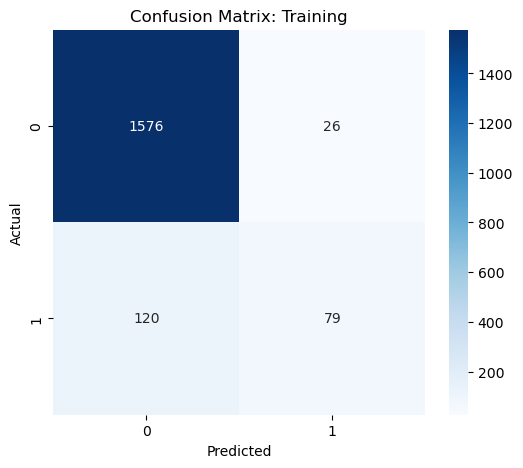

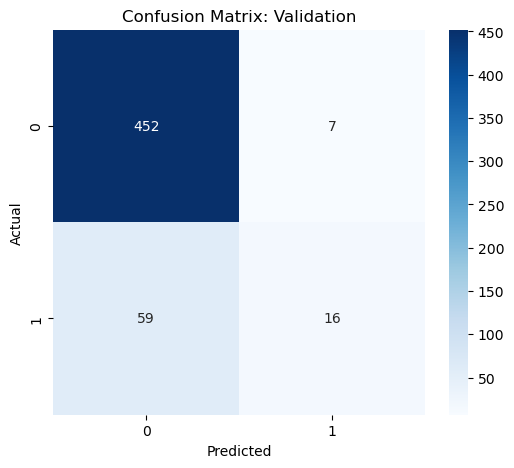

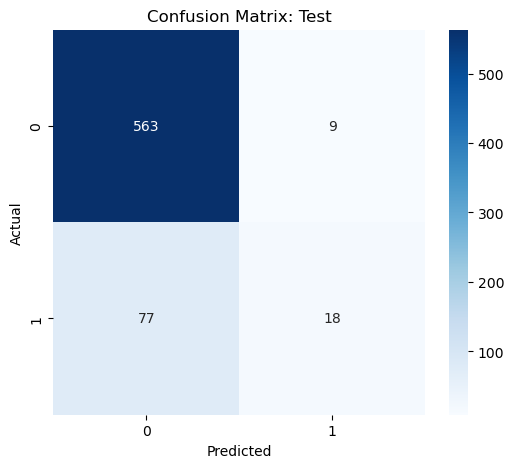


Evaluating Decision Tree...
Metrics for DecisionTreeClassifier:
  Train:
    Accuracy: 1.0000
    Precision: 1.0000
    Recall: 1.0000
    F1 Score: 1.0000
  Validation:
    Accuracy: 0.8708
    Precision: 0.5429
    Recall: 0.5067
    F1 Score: 0.5241
  Test:
    Accuracy: 0.9025
    Precision: 0.7027
    Recall: 0.5474
    F1 Score: 0.6154


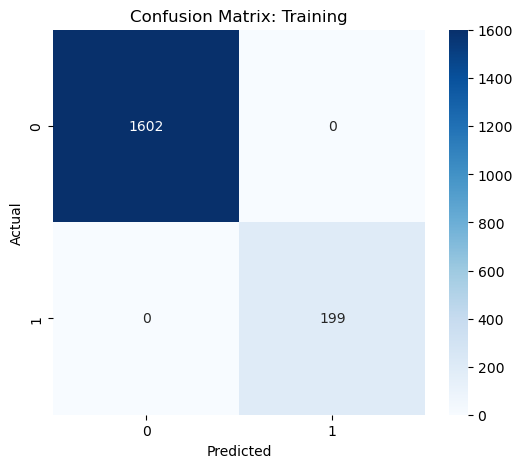

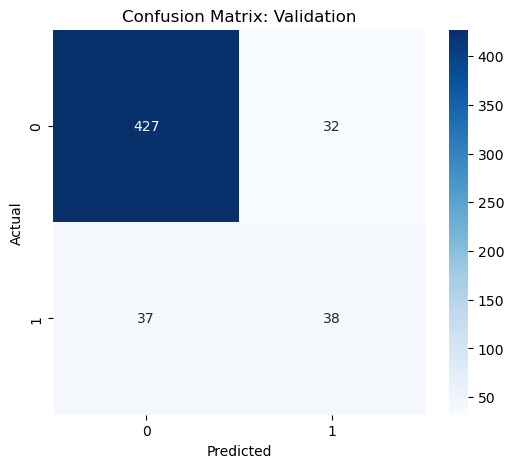

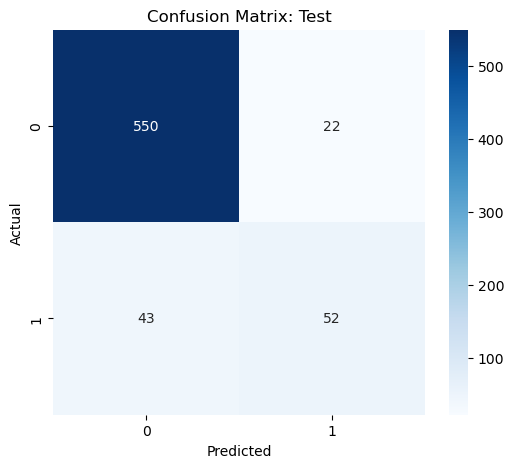


Evaluating Random Forest...
Metrics for RandomForestClassifier:
  Train:
    Accuracy: 1.0000
    Precision: 1.0000
    Recall: 1.0000
    F1 Score: 1.0000
  Validation:
    Accuracy: 0.9195
    Precision: 1.0000
    Recall: 0.4267
    F1 Score: 0.5981
  Test:
    Accuracy: 0.9145
    Precision: 0.9318
    Recall: 0.4316
    F1 Score: 0.5899


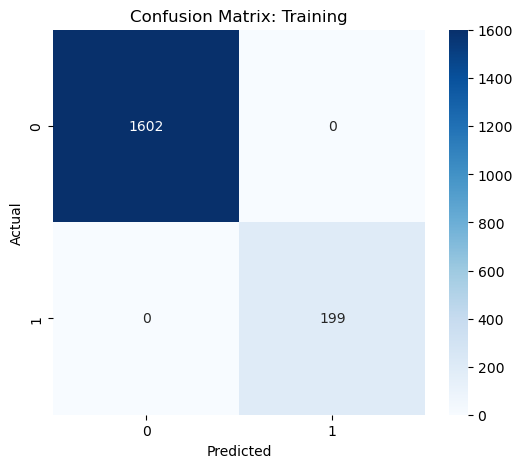

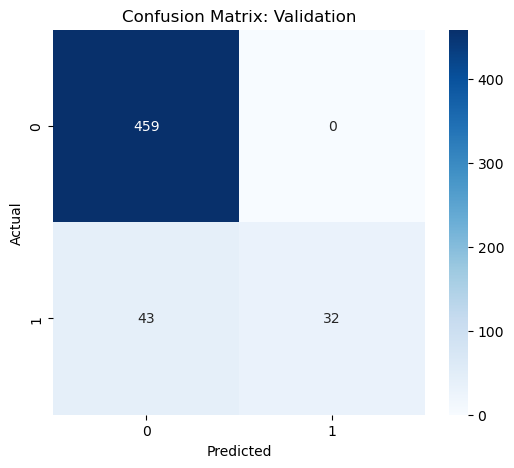

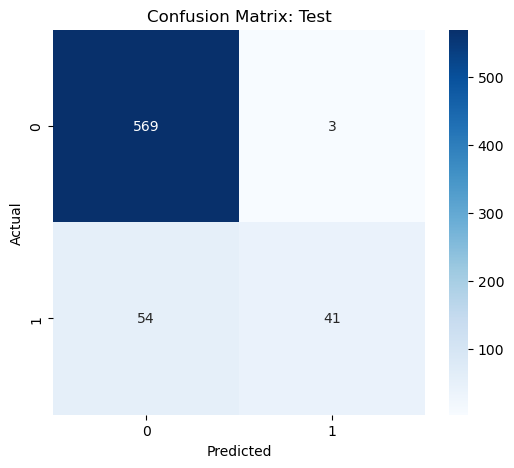


Evaluating Gradient Boosting...
Metrics for GradientBoostingClassifier:
  Train:
    Accuracy: 0.9789
    Precision: 1.0000
    Recall: 0.8090
    F1 Score: 0.8944
  Validation:
    Accuracy: 0.9288
    Precision: 0.9744
    Recall: 0.5067
    F1 Score: 0.6667
  Test:
    Accuracy: 0.9325
    Precision: 0.9464
    Recall: 0.5579
    F1 Score: 0.7020


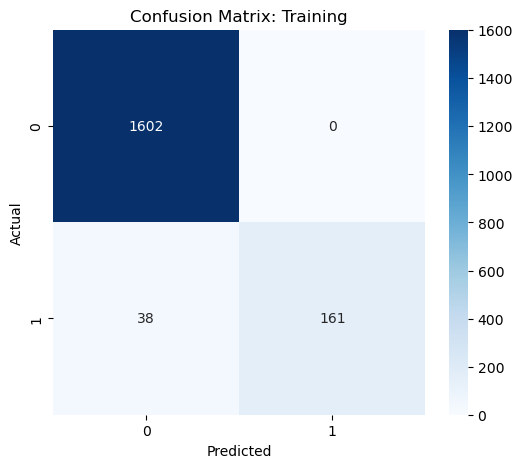

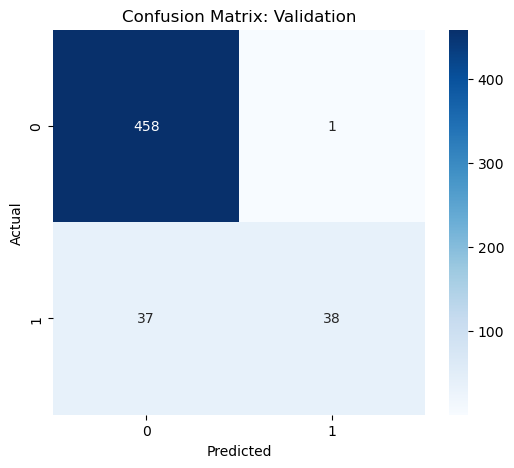

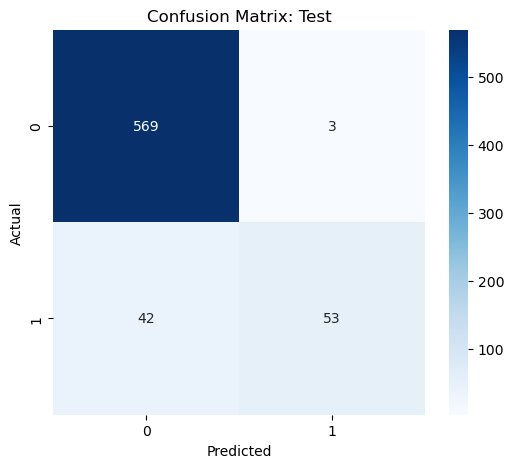

In [88]:
# List of models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Evaluate each model
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    evaluate_model(model, x_train, y_train, x_val, y_val, x_test, y_test)

## The results for models like Logistic Regression, Decision Trees and Random Forests indicate overfitting. However, Gradient Bossting is the best model and generalizes well to unseen data compared to others.